# CUSTOMER SERVICE REQUEST ANALYSIS

## Final Data Analytics 


### Introduction

This project analyzes NYC 311 customer service request data. 
The main objective is to identify complaint patterns, analyze response times, clean the dataset, and visualize complaint distributions across different cities using Python data analytics libraries.


### Objectives

- Understand the dataset
- Perform data cleaning
- Handle missing values
- Analyze complaint patterns
- Visualize complaints across cities
- Calculate complaint response times
- Perform statistical analysis
- Draw conclusions from the dataset

In [15]:
!pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.3 MB ? eta -:--:--
    --------------------------------------- 0.5/37.3 MB 784.7 kB/s eta 0:00:47
    --------------------------------------- 0.5/37.3 MB 784.7 kB/s eta 0:00:47
    --------------------------------------- 0.8/37.3 MB 773.1 kB/s eta 0:00:48
   - -------------------------------------- 1.0/37.3 MB 820.5 kB/s eta 0:00:45
   - -------------------------------------- 1.3/37.3 MB 884.9 kB/s eta 0:00:41
   - -------------------------------------- 1.6/37.3 MB 908.0 kB/s eta 0:00:40
   - -------------------------------------- 1.8/37.3 MB 944.5 kB/s eta 0:00:38
   - --------------


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal

In [17]:
# 2. Load Dataset
df = pd.read_csv(
    r"C:\Users\DELL\Downloads\311-service-requests-nyc\311_Service_Requests_from_2010_to_Present.csv",
    nrows=50000,
    low_memory=False
)

In [18]:
# 4. Dataset Columns
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [19]:
# 4. Dataset Columns
print(df.columns)

Index(['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name',
       'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip',
       'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2',
       'Intersection Street 1', 'Intersection Street 2', 'Address Type',
       'City', 'Landmark', 'Facility Type', 'Status', 'Due Date',
       'Resolution Description', 'Resolution Action Updated Date',
       'Community Board', 'Borough', 'X Coordinate (State Plane)',
       'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough',
       'School Name', 'School Number', 'School Region', 'School Code',
       'School Phone Number', 'School Address', 'School City', 'School State',
       'School Zip', 'School Not Found', 'School or Citywide Complaint',
       'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location',
       'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp',
       'Bridge Highway Segment', 'Garage Lot Name', 'Ferry 

In [20]:
# 5. Dataset Shape
print(df.shape)

(50000, 53)


In [21]:
# 6. Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unique Key                      50000 non-null  int64  
 1   Created Date                    50000 non-null  object 
 2   Closed Date                     49725 non-null  object 
 3   Agency                          50000 non-null  object 
 4   Agency Name                     50000 non-null  object 
 5   Complaint Type                  50000 non-null  object 
 6   Descriptor                      49283 non-null  object 
 7   Location Type                   50000 non-null  object 
 8   Incident Zip                    49679 non-null  float64
 9   Incident Address                44212 non-null  object 
 10  Street Name                     44212 non-null  object 
 11  Cross Street 1                  43457 non-null  object 
 12  Cross Street 2                  

In [22]:
# 7. Statistical Summary
df.describe()

,Unique Key,Incident Zip,X Coordinate (State Plane),Y Coordinate (State Plane),School or Citywide Complaint,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude
count,5.000000e+04,49679.000000,4.957000e+04,49570.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49570.000000,49570.000000
mean,3.213919e+07,10878.535659,1.004405e+06,201492.829453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.719676,-73.927250
std,1.000917e+05,573.342338,2.237173e+04,29372.470018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.080616,0.080685
min,3.195831e+07,83.000000,9.133570e+05,121998.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.501279,-74.254937
25%,3.205144e+07,10451.000000,9.905112e+05,180425.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.661839,-73.977418
50%,3.214385e+07,11211.000000,1.002814e+06,199696.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.714699,-73.933049
75%,3.222533e+07,11249.000000,1.019534e+06,218576.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.766533,-73.872715
max,3.231065e+07,11697.000000,1.067154e+06,271391.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.911533,-73.700837


In [23]:
# 8. Missing Value Analysis
print(df.isnull().sum())

Unique Key                            0
Created Date                          0
Closed Date                         275
Agency                                0
Agency Name                           0
Complaint Type                        0
Descriptor                          717
Location Type                         0
Incident Zip                        321
Incident Address                   5788
Street Name                        5788
Cross Street 1                     6543
Cross Street 2                     6597
Intersection Street 1             44267
Intersection Street 2             44326
Address Type                        367
City                                322
Landmark                          49975
Facility Type                       270
Status                                0
Due Date                              0
Resolution Description                0
Resolution Action Updated Date      270
Community Board                       0
Borough                               0


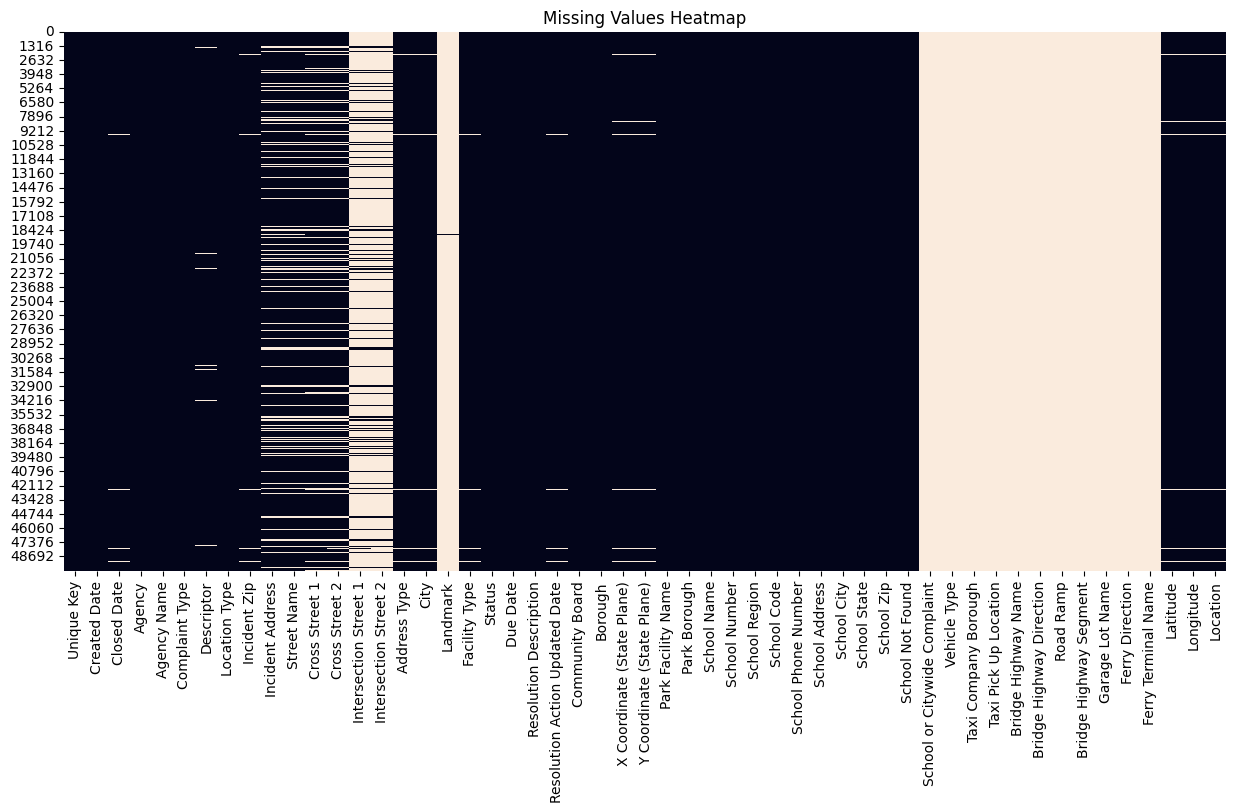

In [24]:
plt.figure(figsize=(15,7))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")

plt.show()

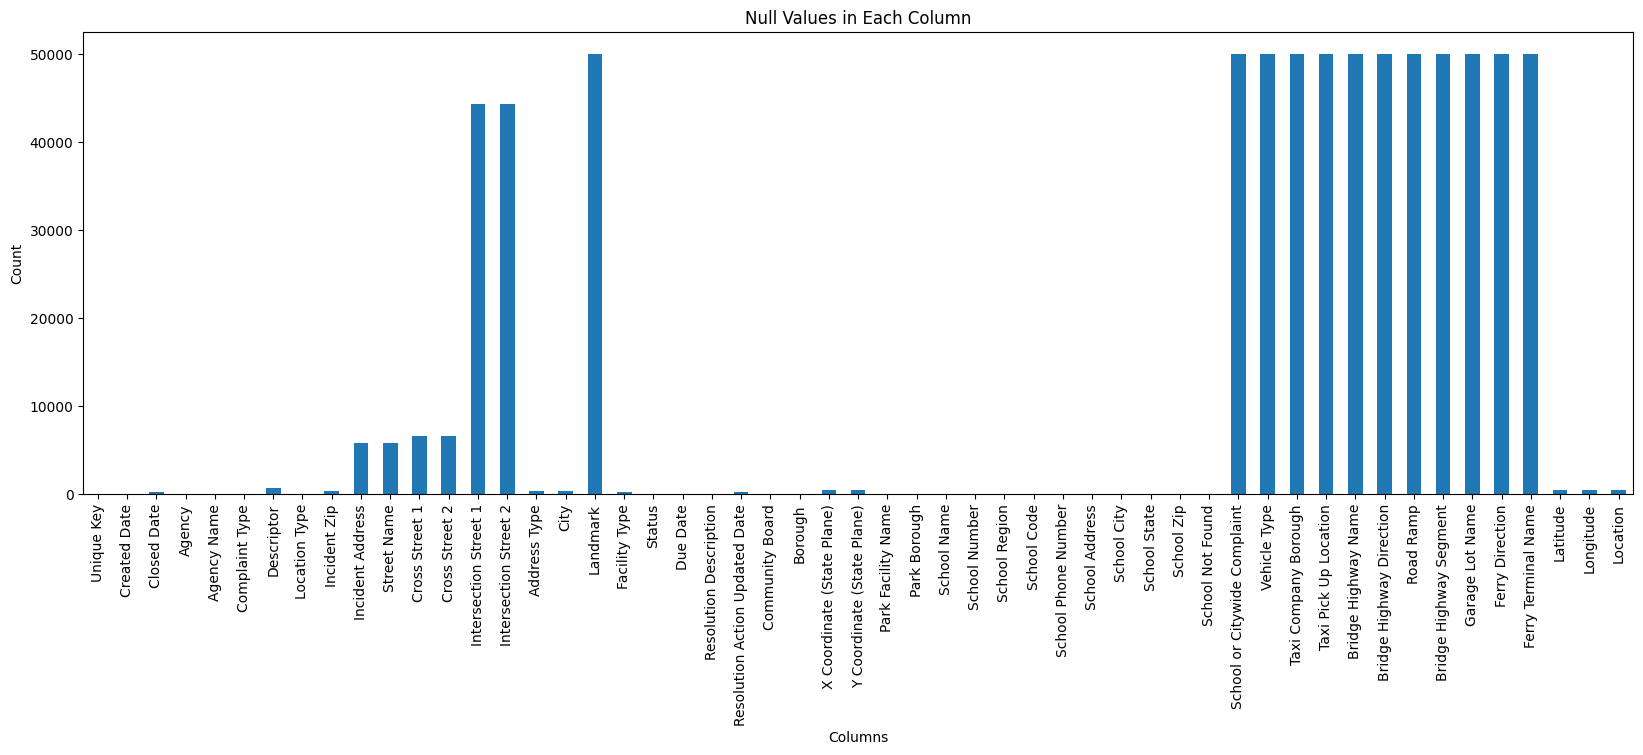

In [26]:
df.isnull().sum().plot(
    kind='bar',
    figsize=(20,6)
)

plt.title("Null Values in Each Column")

plt.xlabel("Columns")
plt.ylabel("Count")

plt.show()

In [27]:
# 9. Data Cleaning
df = df[df['Closed Date'].notnull()]

In [29]:
df['Created Date'] = pd.to_datetime(df['Created Date'])
df['Closed Date'] = pd.to_datetime(df['Closed Date'])

In [30]:
df = df[
    df['Closed Date'] >= df['Created Date']
]

In [31]:
# 10. Request Closing Time Analysis
df['Request_Closing_Time'] = (
    df['Closed Date'] - df['Created Date']
)

In [32]:
df['Request_Closing_Time'] = (
    df['Request_Closing_Time']
    .dt.total_seconds()
)

In [33]:
df['Request_Closing_Time'].describe()

count    4.972500e+04
mean     1.699324e+04
std      2.967123e+04
min      1.460000e+02
25%      4.697000e+03
50%      9.945000e+03
75%      1.971100e+04
max      2.078466e+06
Name: Request_Closing_Time, dtype: float64

In [34]:
print(df['City'].isnull().sum())

61


In [35]:
df['City'].fillna(
    "Unknown City",
    inplace=True
)

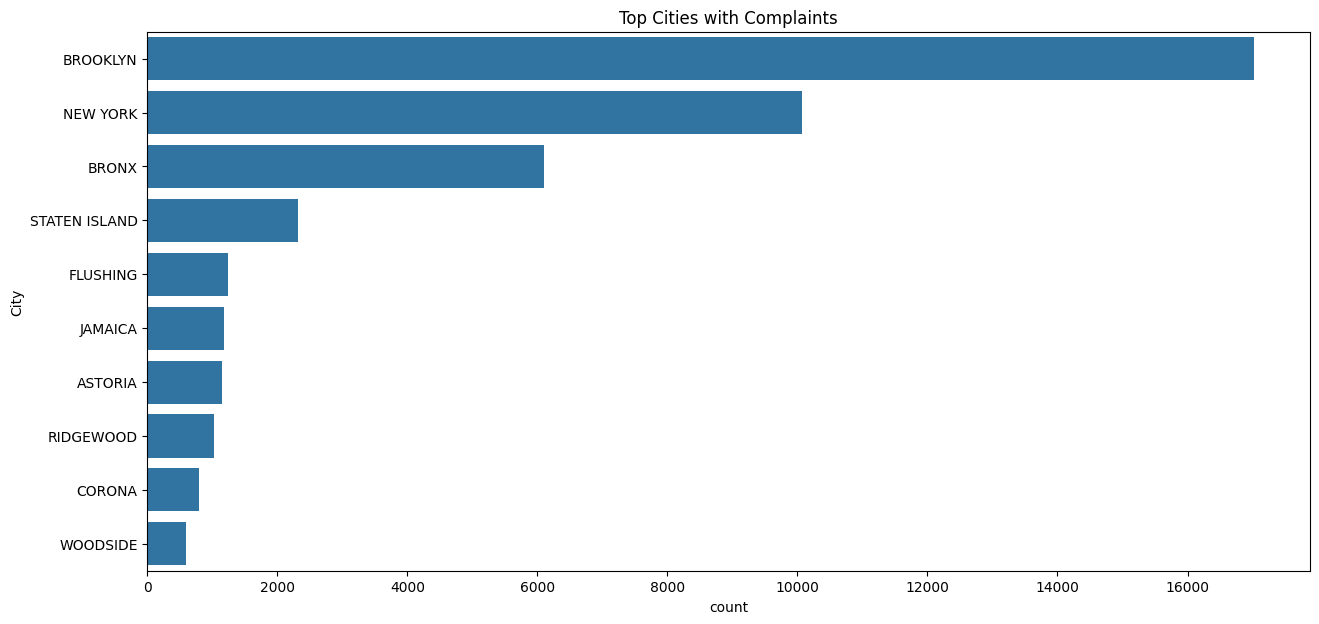

In [36]:
# 11. Complaints by City
plt.figure(figsize=(15,7))

sns.countplot(
    data=df,
    y='City',
    order=df['City'].value_counts().index[:10]
)

plt.title("Top Cities with Complaints")

plt.show()

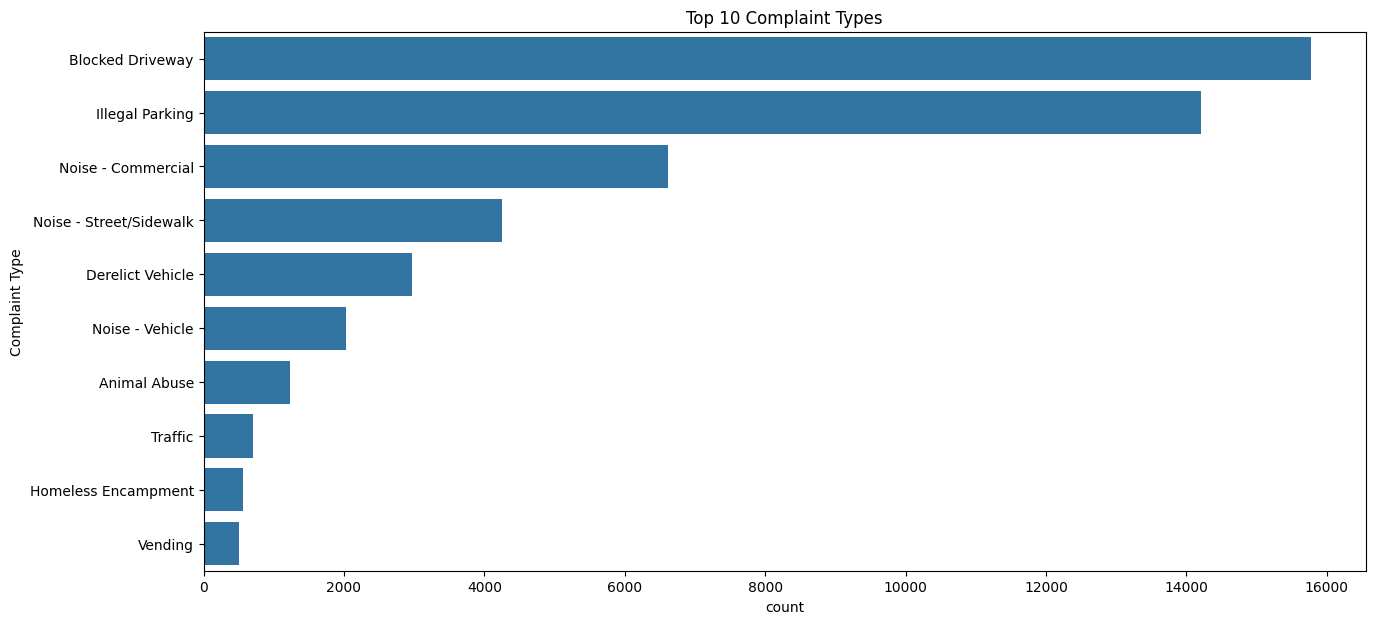

In [37]:
plt.figure(figsize=(15,7))

sns.countplot(
    data=df,
    y='Complaint Type',
    order=df['Complaint Type'].value_counts().index[:10]
)

plt.title("Top 10 Complaint Types")

plt.show()

In [38]:
top10 = (
    df['Complaint Type']
    .value_counts()
    .head(10)
)

print(top10)

Complaint Type
Blocked Driveway           15771
Illegal Parking            14209
Noise - Commercial          6616
Noise - Street/Sidewalk     4253
Derelict Vehicle            2975
Noise - Vehicle             2034
Animal Abuse                1231
Traffic                      700
Homeless Encampment          566
Vending                      506
Name: count, dtype: int64


In [39]:
nyc = df[df['City'] == 'NEW YORK']

print(
    nyc['Complaint Type']
    .value_counts()
)

Complaint Type
Noise - Commercial           3023
Illegal Parking              2183
Noise - Street/Sidewalk      2021
Noise - Vehicle               866
Blocked Driveway              389
Homeless Encampment           375
Vending                       307
Traffic                       285
Animal Abuse                  272
Derelict Vehicle              125
Noise - Park                   84
Drinking                       35
Panhandling                    30
Urinating in Public            20
Noise - House of Worship       19
Bike/Roller/Skate Chronic      18
Posting Advertisement           8
Graffiti                        2
Disorderly Youth                2
Name: count, dtype: int64


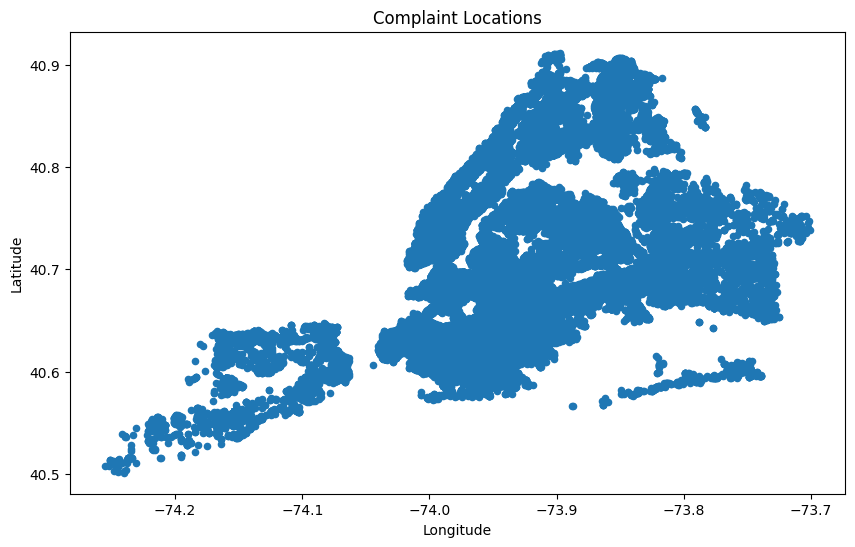

In [40]:
# 13. Complaint Location Analysis
df.plot.scatter(
    x='Longitude',
    y='Latitude',
    figsize=(10,6)
)

plt.title("Complaint Locations")

plt.show()

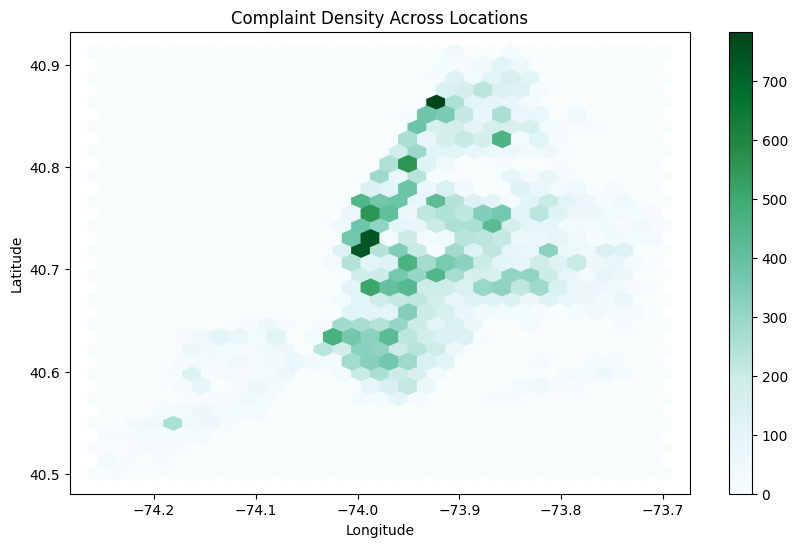

In [41]:
df.plot.hexbin(
    x='Longitude',
    y='Latitude',
    gridsize=30,
    figsize=(10,6)
)

plt.title("Complaint Density Across Locations")

plt.show()

In [42]:
# 14. Complaint Types Across Cities
city_complaints = pd.crosstab(
    df['City'],
    df['Complaint Type']
)

print(city_complaints)

Complaint Type       Animal Abuse  Bike/Roller/Skate Chronic  \
City                                                           
ARVERNE                         5                          0   
ASTORIA                        21                          7   
BAYSIDE                         5                          0   
BELLEROSE                       1                          0   
BREEZY POINT                    0                          0   
BRONX                         245                          5   
BROOKLYN                      325                          8   
CAMBRIA HEIGHTS                 0                          0   
CENTRAL PARK                    0                          0   
COLLEGE POINT                   3                          0   
CORONA                          2                          0   
EAST ELMHURST                   9                          0   
ELMHURST                        6                          0   
FAR ROCKAWAY                   21       

In [43]:
df_new = city_complaints.transpose()

print(df_new)

City                       ARVERNE  ASTORIA  BAYSIDE  BELLEROSE  BREEZY POINT  \
Complaint Type                                                                  
Animal Abuse                     5       21        5          1             0   
Bike/Roller/Skate Chronic        0        7        0          0             0   
Blocked Driveway                 5      546       60         17             1   
Derelict Vehicle                 7       55       31          7             0   
Disorderly Youth                 0        0        0          0             0   
Drinking                         0        4        0          0             0   
Graffiti                         0        0        2          0             0   
Homeless Encampment              1        4        1          0             0   
Illegal Fireworks                0        0        0          0             0   
Illegal Parking                 15      251       93          7             0   
Noise - Commercial          

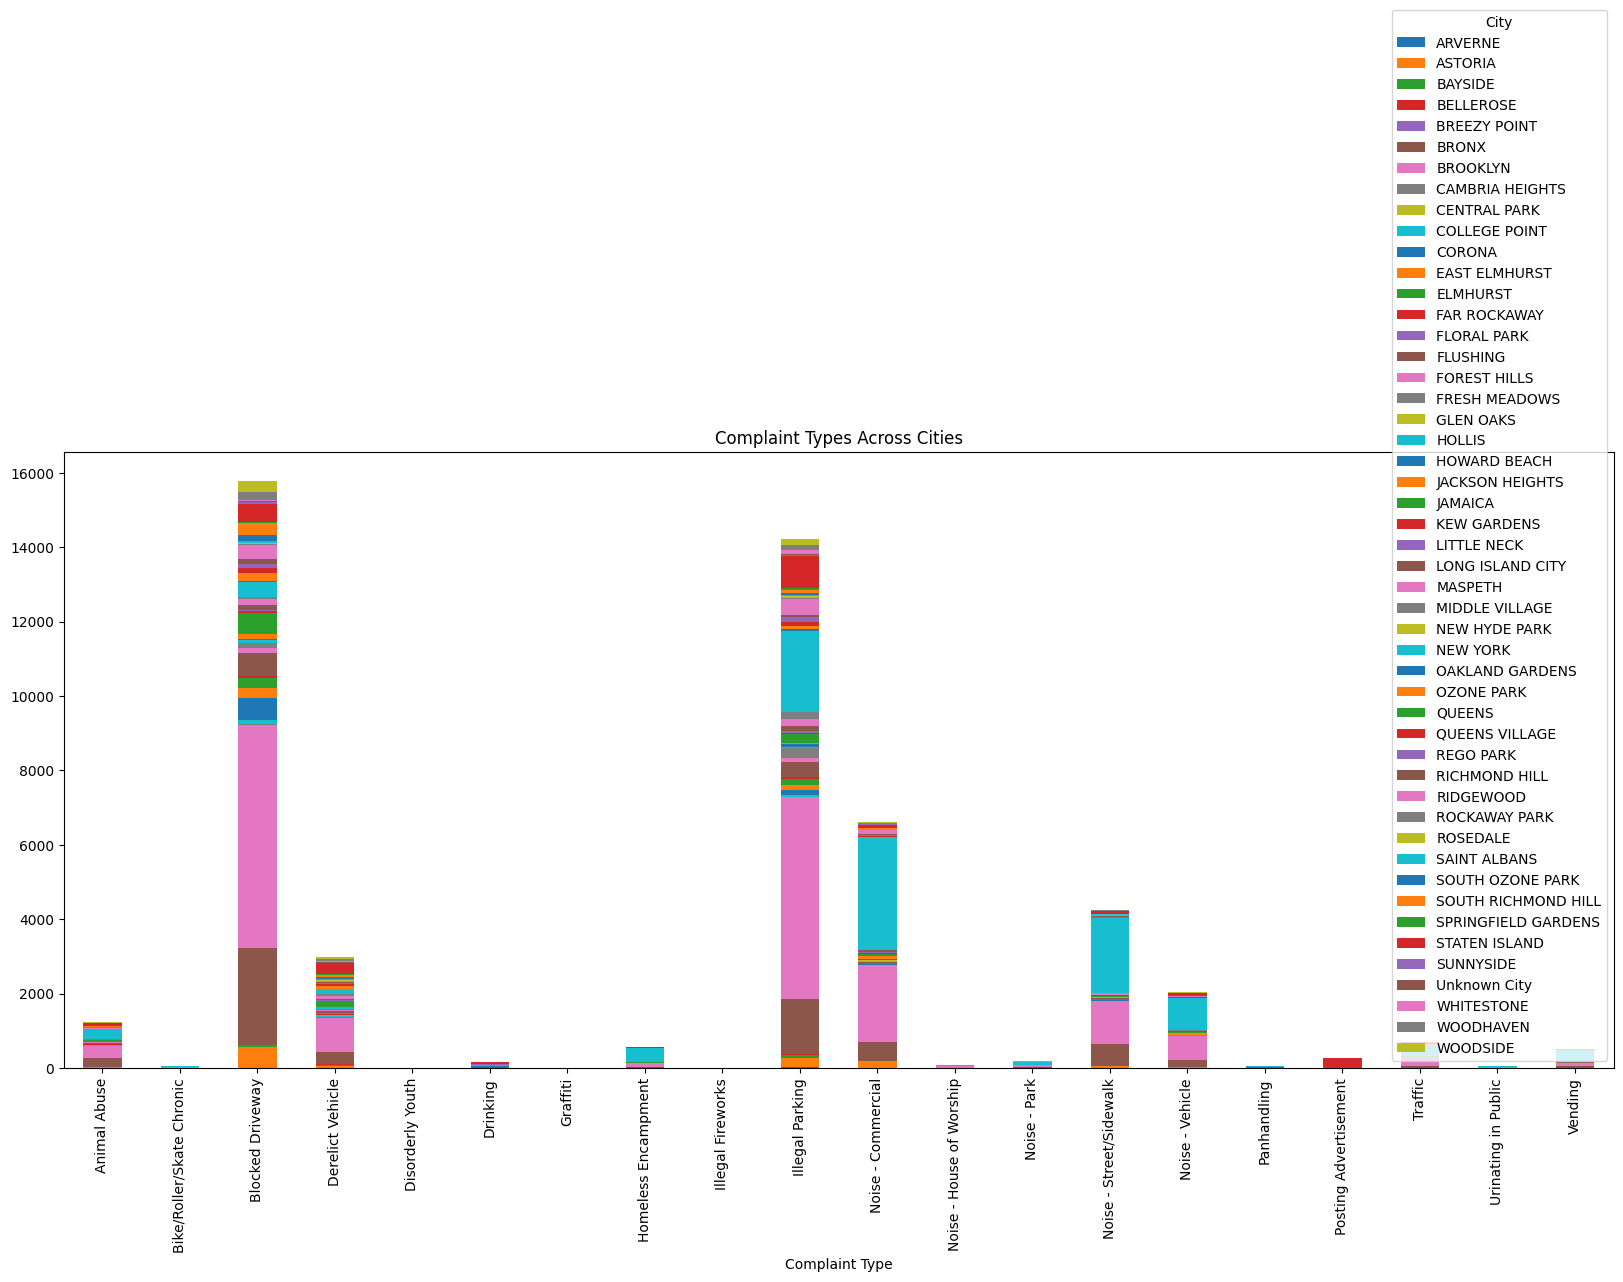

In [44]:
df_new.plot(
    kind='bar',
    stacked=True,
    figsize=(20,8)
)

plt.title("Complaint Types Across Cities")

plt.show()

In [46]:
# 15. Average Response Time Analysis
avg_time = df.groupby(
    'Complaint Type'
)['Request_Closing_Time'].mean()


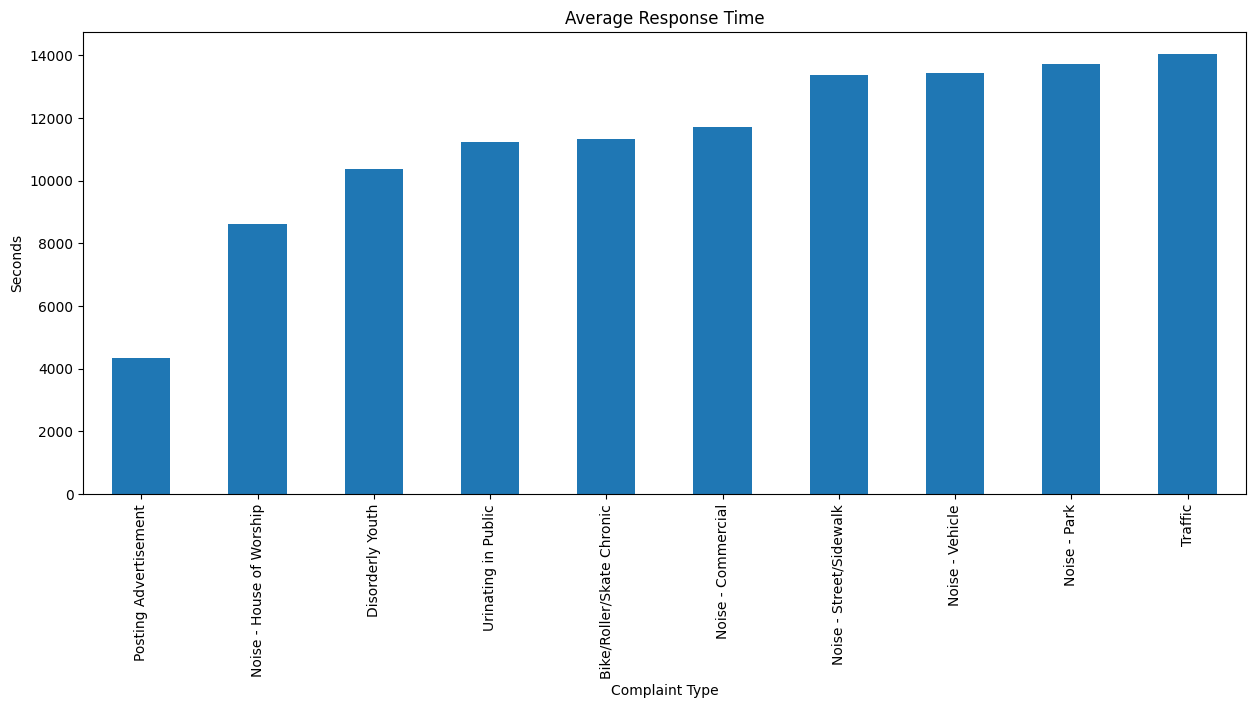

In [47]:
avg_time.sort_values().head(10).plot(
    kind='bar',
    figsize=(15,6)
)

plt.title("Average Response Time")

plt.ylabel("Seconds")

plt.show()

In [48]:
# 16. Statistical Analysis
complaints = df[
    'Complaint Type'
].dropna().unique()[:3]

data = []

for c in complaints:
    
    temp = df[
        df['Complaint Type'] == c
    ]['Request_Closing_Time']
    
    data.append(temp)

stat, p = kruskal(*data)

print("P-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

P-value: 1.2108699668454152e-112
Reject H0


In [49]:
complaints = df[
    'Complaint Type'
].dropna().unique()[:3]

data = []

for c in complaints:
    
    temp = df[
        df['Complaint Type'] == c
    ]['Request_Closing_Time']
    
    data.append(temp)

stat, p = kruskal(*data)

print("P-value:", p)

if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

P-value: 1.2108699668454152e-112
Reject H0


### Interpretation

If p-value is less than 0.05, response times differ significantly across complaint categories.
Otherwise, complaint response distributions are similar.

### Conclusion

The analysis revealed important complaint patterns across NYC. 
Noise-related complaints were among the most common complaint categories. 
Brooklyn and New York City recorded the highest number of complaints. 
Response times varied across complaint categories, and statistical analysis helped identify significant differences in complaint resolution times.